In [1]:
!pip show numpy

Name: numpy
Version: 2.5.3
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License-Expression: BSD-3-Clause AND 0BSD AND MIT AND Zlib AND CC0-1.0
Location: D:\programming\ML\my_simple_models\.venv\Lib\site-packages
Requires: 
Required-by: contourpy, matplotlib, pandas


In [2]:
import numpy as np

In [17]:
x = np.linspace(-40, 40, 20)

rng = np.random.default_rng(1234)
y = 32 * x + 3 + rng.normal(0, 10, 20)

w_true, b_true = 32, 3

y_clean = w_true * x + b_true
y += rng.normal(0, 0.5 * y_clean.std(), x.shape)

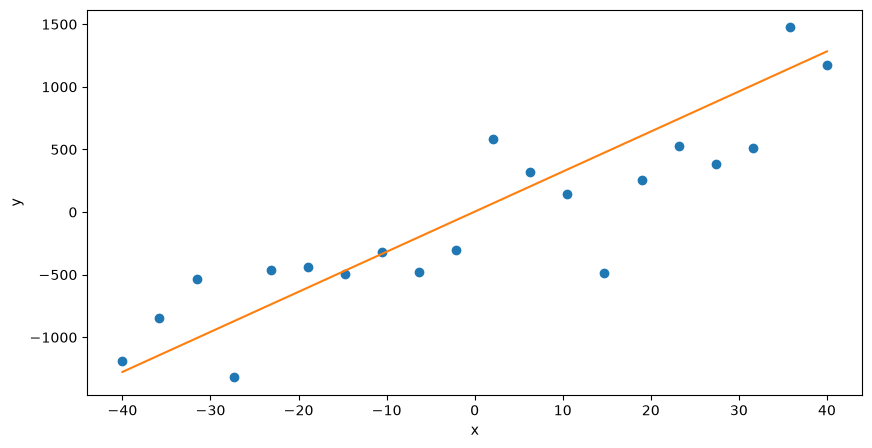

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(x, y, "o")
plt.plot(x, y_clean, "-")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
def MSE(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

class MyLinearRegression:
    def __init__(self):
        self.w = 1
        self.b = 1

    def forward(self, x):
        return self.w * x + self.b

    def backward(self, x, lr, dL_ds):
        dL_dw = np.mean(dL_ds * -x)
        dL_db = np.mean(dL_ds * -1)

        self.w -= dL_dw * lr
        self.b -= dL_db * lr

    def get_params(self):
        return self.w, self.b

In [49]:
def fit(model, X, y_true, epochs=100, lr=0.001):
    for epoch in range(epochs):
        y_pred = model.forward(X)
        loss = MSE(y_true, y_pred)

        dL_ds = 2 * (y_true - y_pred)
        model.backward(X, lr, dL_ds)

        print(f"Epoch: {epoch}, Loss: {loss}")
        print(f"Params: {model.get_params()}")

In [50]:
model = MyLinearRegression()
fit(model, x, y_clean)

Epoch: 0, Loss: 566488.2105263157
Params: (array([37.54736842, 37.54736842, 37.54736842, 37.54736842, 37.54736842,
       37.54736842, 37.54736842, 37.54736842, 37.54736842, 37.54736842,
       37.54736842, 37.54736842, 37.54736842, 37.54736842, 37.54736842,
       37.54736842, 37.54736842, 37.54736842, 37.54736842, 37.54736842]), np.float64(1.004))
Epoch: 1, Loss: 18144.032419557363
Params: (array([31.00731302, 31.00731302, 31.00731302, 31.00731302, 31.00731302,
       31.00731302, 31.00731302, 31.00731302, 31.00731302, 31.00731302,
       31.00731302, 31.00731302, 31.00731302, 31.00731302, 31.00731302,
       31.00731302, 31.00731302, 31.00731302, 31.00731302, 31.00731302]), np.float64(1.007992))
Epoch: 2, Loss: 584.8516403183855
Params: (array([32.17763872, 32.17763872, 32.17763872, 32.17763872, 32.17763872,
       32.17763872, 32.17763872, 32.17763872, 32.17763872, 32.17763872,
       32.17763872, 32.17763872, 32.17763872, 32.17763872, 32.17763872,
       32.17763872, 32.17763872, 